Exploratory Data Analysis reprezintă procesul detaliat prin care investigăm, explorăm și înțelegem datele înainte de a implementa modele predictive sau statistice.

Obiectivele EDA includ:

Explorarea structurii datelor.

*   Identificarea valorilor lipsă și tratarea acestora.
*   Detectarea și gestionarea valorilor aberante (outliers)
*   Vizualizarea și înțelegerea relațiilor dintre variabile.
*   Identificarea variabilelor relevante pentru predicție.
*   


Scopul final: Pregătirea datelor pentru un model performant și evitarea erorilor în fazele ulterioare.



 Pasul 1: Importarea și încărcarea datelor

In [382]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = pd.read_csv('AB_NYC_2019.csv')

# Verificare dimensiuni și tipuri
print(df.shape)
print(df.info())
print(df.head())

(48895, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review         

**id (int64)**


**Rol:** identificator unic.

De obicei nu are valoare predictivă. Dacă este folosit ca feature, poate genera supraajustare (overfitting). Recomandarea e să-l eliminăm din caracteristicile modelului, deoarece reprezintă doar o identificare internă.

**name și host_name (object)**

Reprezintă numele proprietății și numele gazdei. Sunt texte libere.
Sunt utile pentru analiza textuală (NLP), dar fără preprocesare nu au valoare numerică directă.

Un model clasic de regresie sau clasificare nu le poate folosi direct.

Ar putea fi folosite doar după vectorizare (TF-IDF) pentru modele NLP avansate.

În mod obișnuit, le excludem dacă nu avem intenția de a folosi NLP.

**host_id (int64)**

ID numeric unic pentru gazdă.
Deși numeric, nu are sens matematic real.

*Util ca feature indirect dacă dorim să analizăm recurența gazdelor (ex: dacă anumite gazde influențează prețurile). Ar putea fi transformat în variabile categorice (one-hot) sau de frecvență (câte proprietăți are o gazdă)*.

**latitude și longitude (float)**

Coordonatele geografice.

Foarte importante pentru predicție spațială și modele care utilizează locația (regresii geografice, modele bazate pe proximitate).

Pot fi utilizate în modele avansate:
 Clustering spațial, algoritmi precum KNN (nearest neighbors) și Haversine distance.

**room_type și neighbourhood (object)**

Variabile categorice clare („Entire home/apt”, „Private room”, etc.).

Foarte utile pentru modele predictive: necesită aplicarea „one-hot encoding” sau target encoding.

Importante în analiza variației prețurilor în funcție de categoria locației.


**price (int64)**

*Variabila-țintă frecventă într-un model de regresie.*

Este numerică, dar poate conține multe outliers. Trebuie analizată atent distribuția și eventual logaritmată pentru predicții mai bune.
Necesită atenție la valori extreme înainte de implementarea unui model.

**last_review și reviews_per_month (object și float64)**

last_review este tip dată, dar încărcat ca obiect. Ar trebui transformat explicit în dată (datetime) pentru analiza de serie temporală.
Feature important în analiză temporală pentru a estima popularitatea recentă a locației.

**minimum_nights și number_of_reviews (int64)**

Features numerice utile în prezicerea interesului pentru o proprietate.
Relația dintre aceste variabile și preț poate fi explorată vizual și statistic.

Pot fi folosite direct ca aribute numerice fără transformare specială, dar atenție la valori extreme (ex: minimum_nights = 365 poate fi un outlier).

**last_review (object - data calendaristică)**

Variabilă temporală utilă pentru evaluarea tendințelor și sezonalității.
Trebuie transformată în tip datetime înainte de folosire:

**neighbourhood_group (object)**

Descriere: reprezintă grupul mai mare de cartiere (borough) din New York, precum: Manhattan, Brooklyn, Queens etc.


Variabilă categorică importantă.
Ajută în captarea variabilității geografice și culturale, deoarece prețurile și cererea pot varia considerabil între cartiere.

**Atentie:**


Unele variabile devin relevante doar în combinație cu altele. Exemplu: „room_type” și „neighbourhood_group” combinate pot genera insight-uri despre variații regionale de preț.


Relația puternică dintre „number_of_reviews” și „reviews_per_month” poate genera redundanță informațională. Selectarea variabilelor devine esențială pentru reducerea complexității. (Colinearitatea:)

Dacă ai intenția să faci predicții temporale (ex. cerere sezonieră), coloana „last_review” este utilă în analiza sezonalității.


Coloanele categorice cu multe valori unice (neighbourhood) sunt dificil de gestionat. Recomandarea este reducerea dimensionalității prin clustering (agregare în grupuri mai mari).






In [383]:
#Stergem coloanele irelevante
cols_to_drop = ['id', 'name', 'host_name', 'host_id']

# Eliminarea coloanelor din DataFrame
df = df.drop(columns=cols_to_drop)

In [384]:
# 6. Analiza statistică descriptivă
print("\nStatistici descriptive pentru coloanele numerice:")
print(df.describe())


Statistici descriptive pentru coloanele numerice:
           latitude     longitude         price  minimum_nights  \
count  48895.000000  48895.000000  48895.000000    48895.000000   
mean      40.728949    -73.952170    152.720687        7.029962   
std        0.054530      0.046157    240.154170       20.510550   
min       40.499790    -74.244420      0.000000        1.000000   
25%       40.690100    -73.983070     69.000000        1.000000   
50%       40.723070    -73.955680    106.000000        3.000000   
75%       40.763115    -73.936275    175.000000        5.000000   
max       40.913060    -73.712990  10000.000000     1250.000000   

       number_of_reviews  reviews_per_month  calculated_host_listings_count  \
count       48895.000000       38843.000000                    48895.000000   
mean           23.274466           1.373221                        7.143982   
std            44.550582           1.680442                       32.952519   
min             0.000000     

In [264]:
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


**Analiza detaliată a valorilor lipsă (NaN)**

Aici avem două aspecte majore:

Evaluăm cât de multe date lipsesc și înțelegem impactul lor asupra analizei ulterioare.

Stabilim strategii clare pentru imputarea sau eliminarea datelor lipsă în funcție de procentajul lor și importanța variabilelor respective.



In [385]:
nan_summary = df.isnull().sum()
nan_percentage = (df.isnull().sum() / len(df)) * 100
print(nan_percentage)

neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.558339
reviews_per_month                 20.558339
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64




Strategii:

Imputare simplă (mediană, mod, medie)

Imputare avansată (folosind modele predictive)

Eliminare coloane (dacă peste 40-50% valori lipsă, poate fi inutilă coloana)

Eliminare rânduri (dacă pierdem puține informații și coloana este foarte importantă)



Număr valori lipsă per coloană:
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Procentul de valori lipsă per coloană:
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.558339
reviews_per_month                 20.5

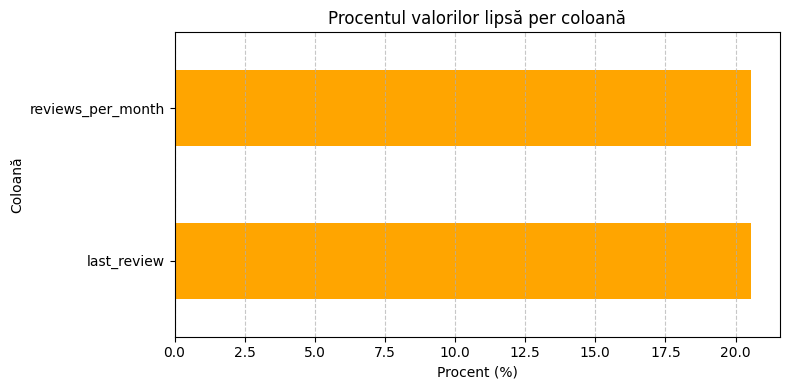

In [386]:
 #4. Analiza valorilor lipsă
print("\nNumăr valori lipsă per coloană:")
missing_vals = df.isnull().sum()
print(missing_vals)

print("\nProcentul de valori lipsă per coloană:")
missing_percent = (missing_vals / len(df)) * 100
print(missing_percent)

# 4.1 Vizualizarea valorilor lipsă
missing_df = pd.DataFrame({
    'Missing Values': missing_vals,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage', ascending=False)

plt.figure(figsize=(8,4))
missing_df['Percentage'].plot(kind='barh', color='orange')
plt.title('Procentul valorilor lipsă per coloană')
plt.xlabel('Procent (%)')
plt.ylabel('Coloană')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [387]:
# 5. Tratarea valorilor lipsă (exemplu simplu)
# Pentru 'reviews_per_month' (care are ~20% lipsă),
# putem face imputare cu mediana pe fiecare 'neighbourhood_group'.
df['reviews_per_month'] = df.groupby('neighbourhood_group')['reviews_per_month'].transform(lambda x: x.fillna(x.median()))

# Pentru 'last_review' transformăm în datetime și notăm rândurile lipsă.
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
# Creăm o coloană binară: are / nu are recenzie recentă
df['has_review'] = df['last_review'].apply(lambda x: 0 if pd.isnull(x) else 1)
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_review
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,1
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,1
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.61,1,365,0
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,1
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,1


In [388]:
# SAU - Preupunem ca daca nu sunt reviews, inseamna ca nimeni nu a facut (mai plauzibil) si inclocuim cu 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
#stergem last review

In [389]:
 #4. Analiza valorilor lipsă
print("\nNumăr valori lipsă per coloană:")
missing_vals = df.isnull().sum()
print(missing_vals)

print("\nProcentul de valori lipsă per coloană:")
missing_percent = (missing_vals / len(df)) * 100
print(missing_percent)



Număr valori lipsă per coloană:
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
has_review                            0
dtype: int64

Procentul de valori lipsă per coloană:
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.55833

exemplu de funcție care primește ca argumente setul de date, metoda de imputare (e.g. "mean", "median", etc.), coloana numerică pe care vrei să o tratezi (e.g. "reviews_per_month"), coloana de tip dată (e.g. "last_review") și coloana de grupare (e.g. "neighbourhood_group").

Funcția execută:

Imputarea valorilor lipsă din coloana numerică, în funcție de metoda specificată, grupat pe coloana de grupare.

Conversia coloanei de tip dată la datetime.

Crearea unei coloane binare "has_review" care marchează dacă există sau nu o dată validă în coloana de tip dată.



In [390]:
def treat_missing_values(df,
                        group_col,        # ex: 'neighbourhood_group'
                        numeric_col,      # ex: 'reviews_per_month'
                        date_col,         # ex: 'last_review'
                        method='median'): # ex: 'mean', 'median', etc.
    """
    Funcție pentru tratarea valorilor lipsă într-o coloană numerică (pe grup) și într-o coloană de tip dată.

    Parametri:
    -----------
    df : pd.DataFrame
        DataFrame-ul care conține datele.
    group_col : str
        Coloana pe baza căreia se grupează (ex: 'neighbourhood_group').
    numeric_col : str
        Coloana numerică unde se face imputarea valorilor lipsă (ex: 'reviews_per_month').
    date_col : str
        Coloana de tip dată unde se face conversia la datetime (ex: 'last_review').
    method : str
        Metoda de imputare pentru numeric_col ('mean' sau 'median', etc.). Implicit 'median'.

    Return:
    -----------
    df : pd.DataFrame
        DataFrame-ul modificat, cu valorile lipsă tratate și o nouă coloană binară ('has_review').
    """

    # 1. Imputarea valorilor lipsă pentru coloana numerică
    if method == 'median':
        df[numeric_col] = df.groupby(group_col)[numeric_col].transform(lambda x: x.fillna(x.median()))
    elif method == 'mean':
        df[numeric_col] = df.groupby(group_col)[numeric_col].transform(lambda x: x.fillna(x.mean()))
    else:
        # Dacă ai nevoie de alte metode (ex: modă, interpolare etc.), le poți adăuga
        raise ValueError("Metoda specificată nu este implementată. Folosește 'mean' sau 'median'.")

    # 2. Conversia coloanei de tip dată la datetime
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # 3. Crearea coloanei binare care indică existența unei recenzii
    df['has_review'] = df[date_col].apply(lambda x: 0 if pd.isnull(x) else 1)

    return df


In [391]:
# Ex.: Imputăm 'reviews_per_month' folosind mediana, grupat pe 'neighbourhood_group',
# apoi transformăm 'last_review' și creăm 'has_review'.
df = treat_missing_values(df,
                         group_col='neighbourhood_group',
                         numeric_col='reviews_per_month',
                         date_col='last_review',
                         method='median')

Analiza distributiei datelor

**Histograme**

Ce fac:

Histogramele împarte valorile unei variabile numerice în intervale (bins) și arată frecvența fiecărui interval.

Dacă histograma prețurilor arată o distribuție puternic asimetrică (spre exemplu, o coadă lungă spre dreapta), acest lucru indică prezența unor valori extreme (outliers) și sugerează că modelul ar putea beneficia de o transformare logaritmică pentru a reduce influența outlier-ilor.

Pentru o variabilă care urmează o distribuție normală, histogramă ar trebui să aibă o formă simetrică. Dacă nu este cazul, poate fi necesară normalizarea datelor pentru modele care presupun normalitatea erorilor (de exemplu, regresia liniară).


**Density plots o**feră o estimare netedă a distribuției datelor și evidențiază forma generală a distribuției fără discontinuități.



Un density plot poate arăta dacă distribuția este unimodală (un singur vârf) sau bimodală/multimodală. De exemplu, dacă ai un density plot pentru prețuri și observi două vârfuri, acest lucru poate indica existența a două segmente de piață (de exemplu, proprietăți de lux versus proprietăți accesibile), ceea ce poate influența strategia de modelare sau segmentarea ulterioară.
Compararea distribuțiilor:
Poți suprapune density plots pentru mai multe categorii (de ex.: room_type) pentru a vedea diferențele.


**Boxplots:**


Un boxplot pentru prețuri poate dezvălui dacă există valori foarte diferite de restul datelor. Dacă se observă multe puncte în afara "cutiei" (whiskers), acestea ar putea distorsiona modelele predictive.
Compararea distribuțiilor între categorii:

De exemplu, un boxplot care compară prețurile în funcție de neighbourhood_group poate evidenția diferențe semnificative între cartiere. Dacă anumite grupuri prezintă o variabilitate mult mai mare, acest lucru ar putea indica că modelul trebuie să trateze aceste segmente în mod diferenția


**Pair Plots și Scatter Plots: **

**Scatter Plots:**

 Arată relația dintre două variabile numerice și pot evidenția relații liniare sau non-liniare, tendințe sau aglomerări de date.

**Pair Plots:**


 Oferă o vedere de ansamblu asupra relațiilor între toate perechile de variabile numerice, inclusiv distribuțiile marginale ale fiecărei variabile.


**Identificarea corelațiilor:**
Dacă un scatter plot între number_of_reviews și price arată o relație pozitivă, acesta sugerează că proprietățile cu mai multe recenzii tind să aibă prețuri mai mari, ceea ce poate fi util în selecția caracteristicilor pentru un model de regresie.
Detectarea relațiilor non-liniare:
Un pair plot poate evidenția relații non-liniare între variabile, indicând faptul că modelele liniare simple ar putea să nu fie adecvate, iar poate fi necesară o transformare a datelor sau utilizarea unor modele non-liniare (ex.: Random Forest, XGBoost).

In [394]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
numerical_cols


Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'has_review'],
      dtype='object')

In [392]:
# Coloane categorice:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['neighbourhood_group', 'neighbourhood', 'room_type'], dtype='object')

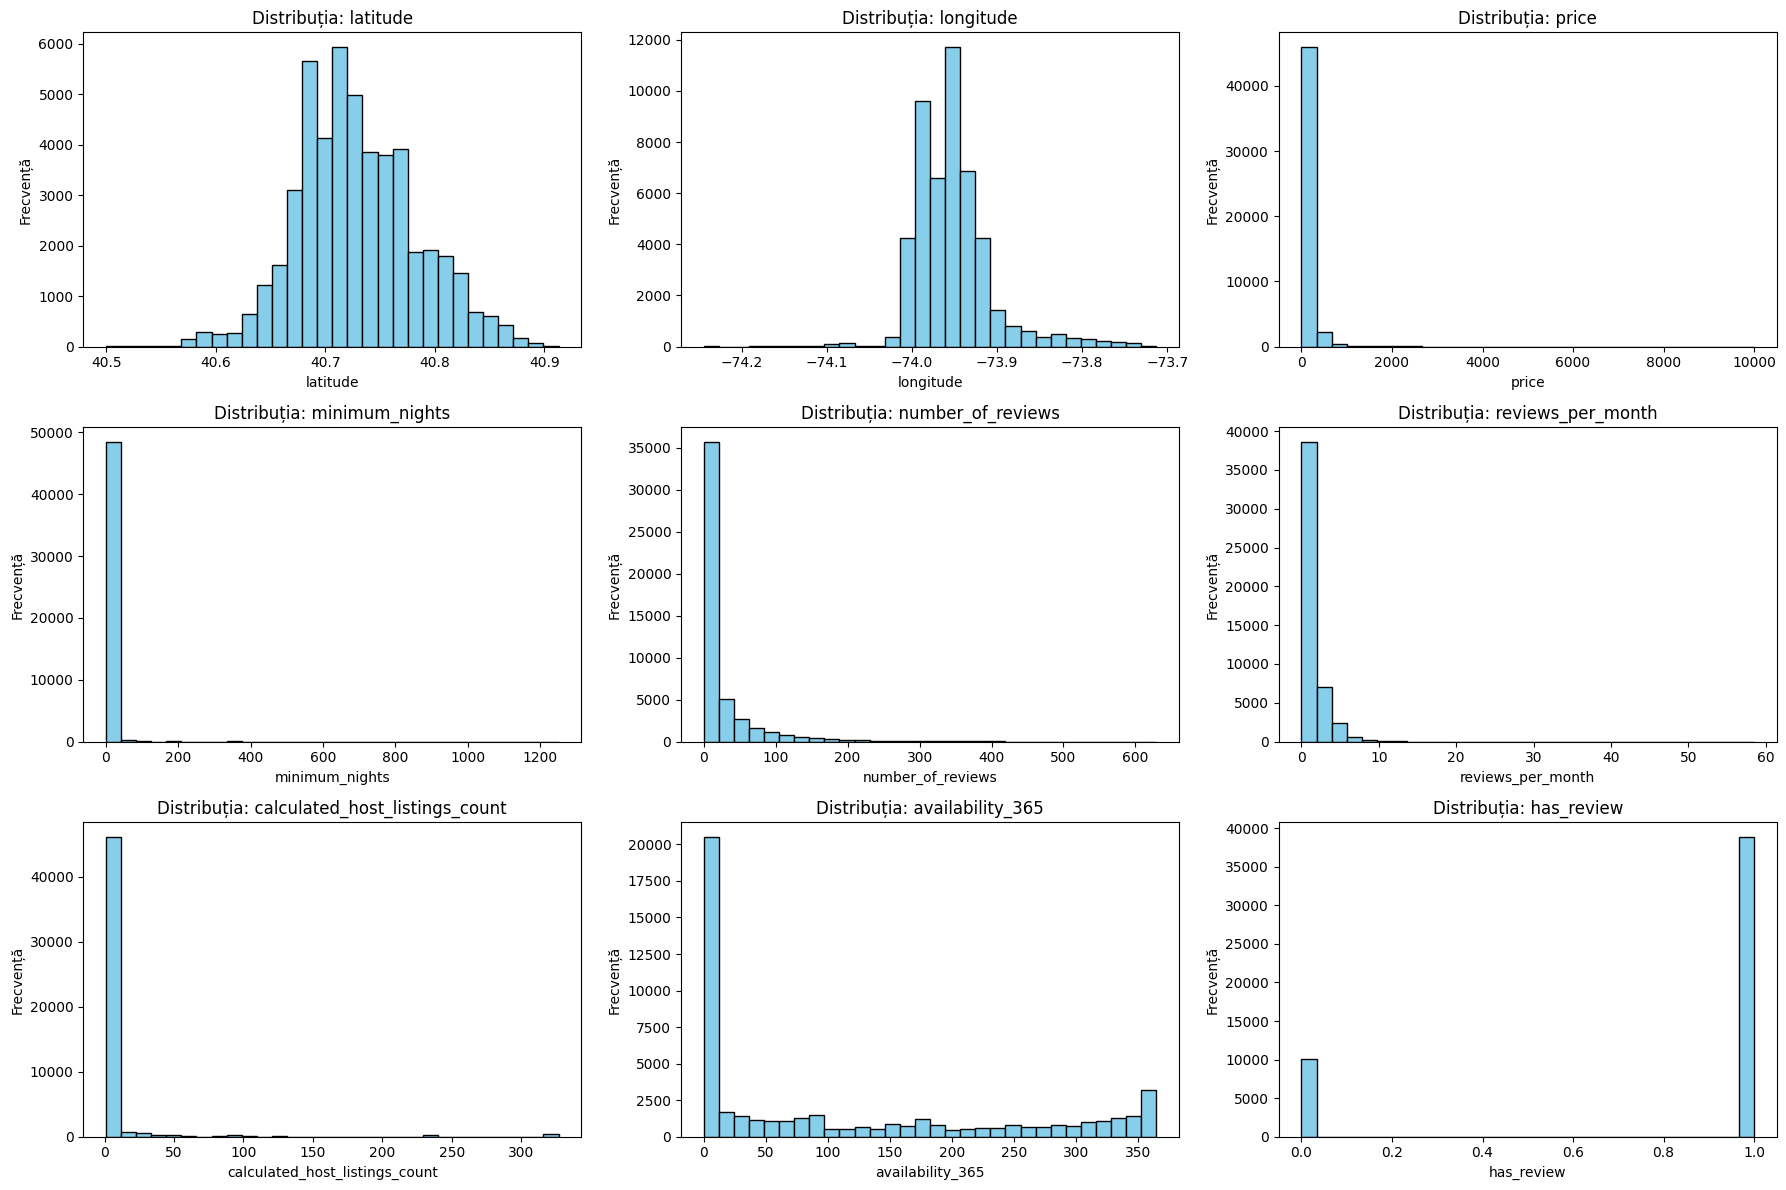

In [395]:
# 3. Generarea histogramelor pentru variabilele numerice
n_cols = 3                                  # Stabilim că dorim 3 grafice pe rând
n_rows = math.ceil(len(numerical_cols) / n_cols)  # Calculăm numărul de rânduri necesare în funcție de numărul total de coloane numerice
plt.figure(figsize=(6 * n_cols, 4 * n_rows))  # Setăm dimensiunea totală a figurii (lățime și înălțime)

# Iterăm prin fiecare coloană numerică și generăm histogramă
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)       # Creăm un subplot în grila de n_rows x n_cols; i+1 pentru indexarea subgraficelor începând de la 1
    plt.hist(df[col].dropna(), bins=30, edgecolor='black', color='skyblue')  # Construim histograma pentru coloana curentă, eliminând valorile lipsă
    plt.title(f'Distribuția: {col}')         # Setăm titlul graficului cu numele coloanei
    plt.xlabel(col)                          # Etichetă pentru axa x, indicând numele variabilei
    plt.ylabel('Frecvență')                    # Etichetă pentru axa y, indicând frecvența valorilor
plt.tight_layout()                          # Ajustăm automat spațiile dintre subgrafice pentru a evita suprapunerea
plt.show()                                  # Afișăm figura cu histogramele

Price: Distribuție extrem de asimetrică (coadă foarte lungă la dreapta). Majoritatea valorilor par concentrate sub 500 de dolari/noapte, însă există și prețuri care depășesc mii de dolari.


Această asimetrie puternică poate afecta modelele liniare și măsurile de eroare sensibile la outliers (ex. MSE).
Adesea se recomandă o transformare logaritmică pentru a reduce influența outlier-ilor și a aduce distribuția mai aproape de una normală.
Trebuie investigat dacă valorile foarte mari sunt date reale (proprietăți de lux) sau erori de introducere a datelor.


minimum_nights

Se observă o concentrare mare a valorilor la intervale mici (1-5 nopți), dar și un număr semnificativ de valori mai mari, ceea ce creează o coadă lungă la dreapta.


Este un indicator important al politicii de închiriere. Valori foarte mari (ex. 365) pot fi outliers sau pot indica proprietăți care închiriază doar pe termen lung.
Dacă scopul este să prezici prețul, e posibil ca aceste valori să aibă un efect semnificativ. Poate fi necesară segmentarea setului de date (termen scurt vs. termen lung).


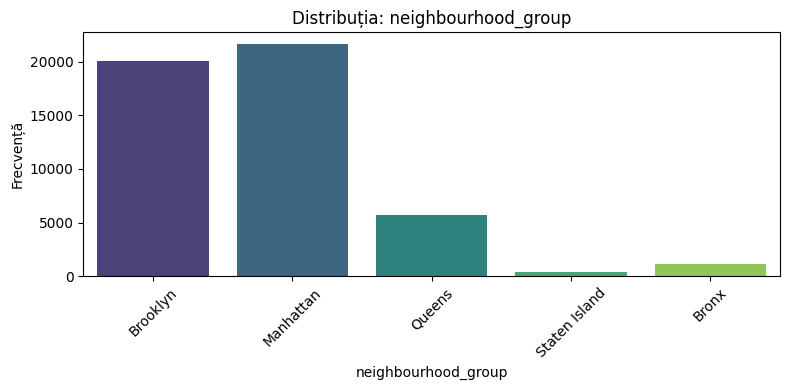

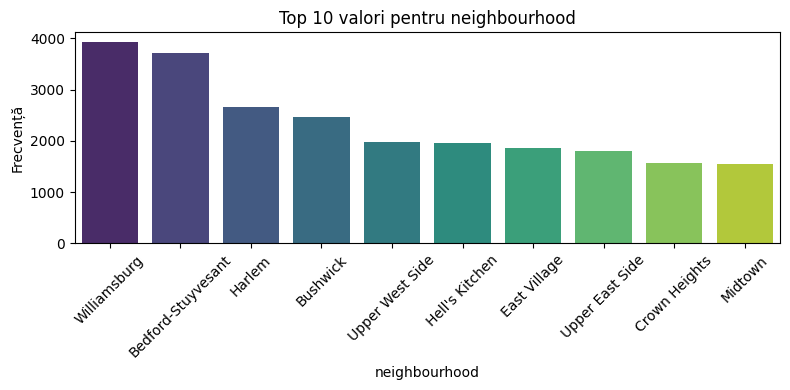

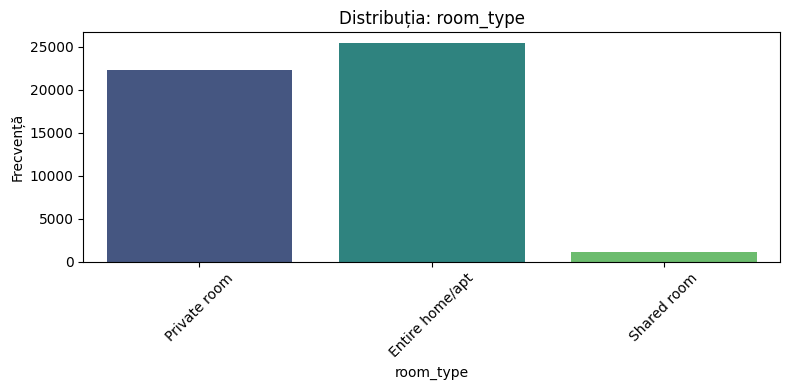

In [396]:

for col in categorical_cols:                # Iterăm prin fiecare coloană de tip obiect (categorică)
    plt.figure(figsize=(8, 4))              # Creăm o figură nouă pentru fiecare coloană categorică
    unique_count = df[col].nunique()         # Calculăm numărul de valori unice din coloana curentă
    if unique_count > 10:                    # Dacă numărul de categorii este mai mare de 10
        # Selectăm top 10 categorii după frecvență
        top_categories = df[col].value_counts().nlargest(10)
        # Construim un barplot folosind cele mai frecvente 10 categorii
        sns.barplot(x=top_categories.index, y=top_categories.values, palette='viridis')
        plt.title(f"Top 10 valori pentru {col}")  # Setăm titlul graficului
        plt.xlabel(col)                      # Etichetă pentru axa x (numele coloanei)
        plt.ylabel("Frecvență")                # Etichetă pentru axa y (numărul de apariții)
        plt.xticks(rotation=45)              # Rotim etichetele de pe axa x pentru o vizibilitate mai bună
    else:
        # Dacă numărul de categorii este mic, construim direct un countplot
        sns.countplot(x=col, data=df, palette='viridis')
        plt.title(f'Distribuția: {col}')     # Setăm titlul graficului
        plt.xlabel(col)                      # Etichetă pentru axa x
        plt.ylabel('Frecvență')                # Etichetă pentru axa y
        plt.xticks(rotation=45)              # Rotim etichetele de pe axa x
    plt.tight_layout()                       # Ajustăm automat spațiile în figură
    plt.show()                               # Afișăm figura pentru coloana categorică

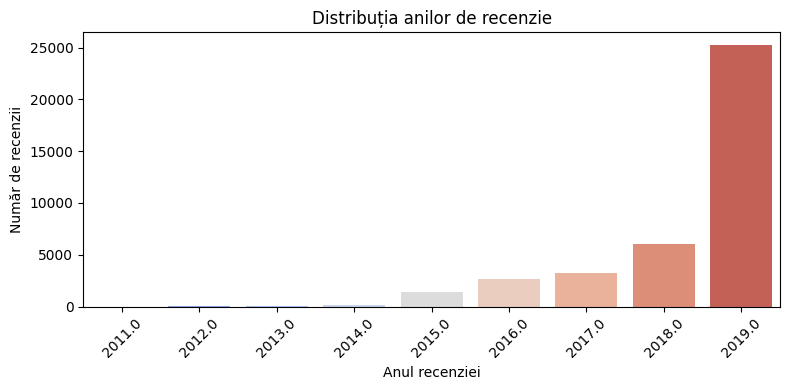

In [397]:
if 'last_review' in df.columns:             # Verificăm dacă coloana 'last_review' există în DataFrame
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')  # Convertim coloana 'last_review' la tip datetime; valorile eronate devin NaT
    df['review_year'] = df['last_review'].dt.year  # Extragem anul din 'last_review' și creăm o nouă coloană 'review_year'
    plt.figure(figsize=(8, 4))              # Creăm o figură de dimensiuni 8x4
    sns.countplot(x='review_year', data=df, palette='coolwarm')  # Construim un countplot pentru distribuția anilor de recenzie
    plt.title("Distribuția anilor de recenzie")  # Setăm titlul graficului
    plt.xlabel("Anul recenziei")             # Etichetă pentru axa x
    plt.ylabel("Număr de recenzii")           # Etichetă pentru axa y
    plt.xticks(rotation=45)                 # Rotim etichetele de pe axa x pentru claritate
    plt.tight_layout()                      # Ajustăm automat spațiul în figură
    plt.show()                              # Afișăm figura pentru datele temporale

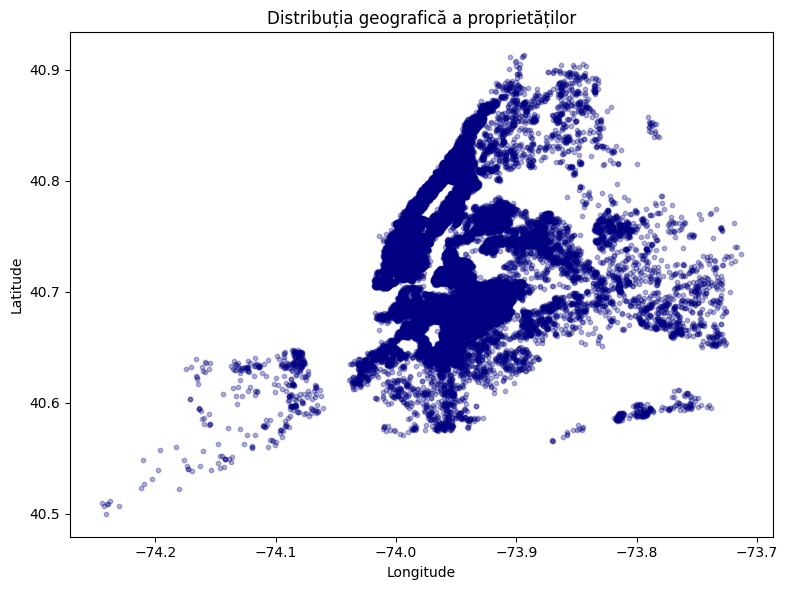

In [398]:
# 6. Generarea graficului geospațial pentru coordonatele 'latitude' și 'longitude'
if 'latitude' in df.columns and 'longitude' in df.columns:  # Verificăm dacă ambele coloane de coordonate există
    plt.figure(figsize=(8, 6))             # Creăm o figură de dimensiuni 8x6
    # Realizăm un scatter plot: longitude pe axa x și latitude pe axa y; folosim alpha pentru transparență și s pentru dimensiunea punctelor
    plt.scatter(df['longitude'], df['latitude'], alpha=0.3, s=10, color='navy')
    plt.title("Distribuția geografică a proprietăților")  # Setăm titlul graficului geospațial
    plt.xlabel("Longitude")                # Etichetă pentru axa x
    plt.ylabel("Latitude")                 # Etichetă pentru axa y
    plt.tight_layout()                     # Ajustăm spațiul din figură
    plt.show()

EXtragere informatii din date


In [399]:
def plot_pairplot_numeric(df, numeric_cols):
    """
    Creează un pairplot pentru variabilele numerice.
    - diag_kind='kde' -> pe diagonală se afișează grafic de densitate
    - corner=True -> afișează doar jumătate din matrice (opțional)
    """
    sns.pairplot(df[numeric_cols], diag_kind='kde')
    plt.suptitle("Pairplot pentru variabilele numerice", y=1.02)
    plt.show()



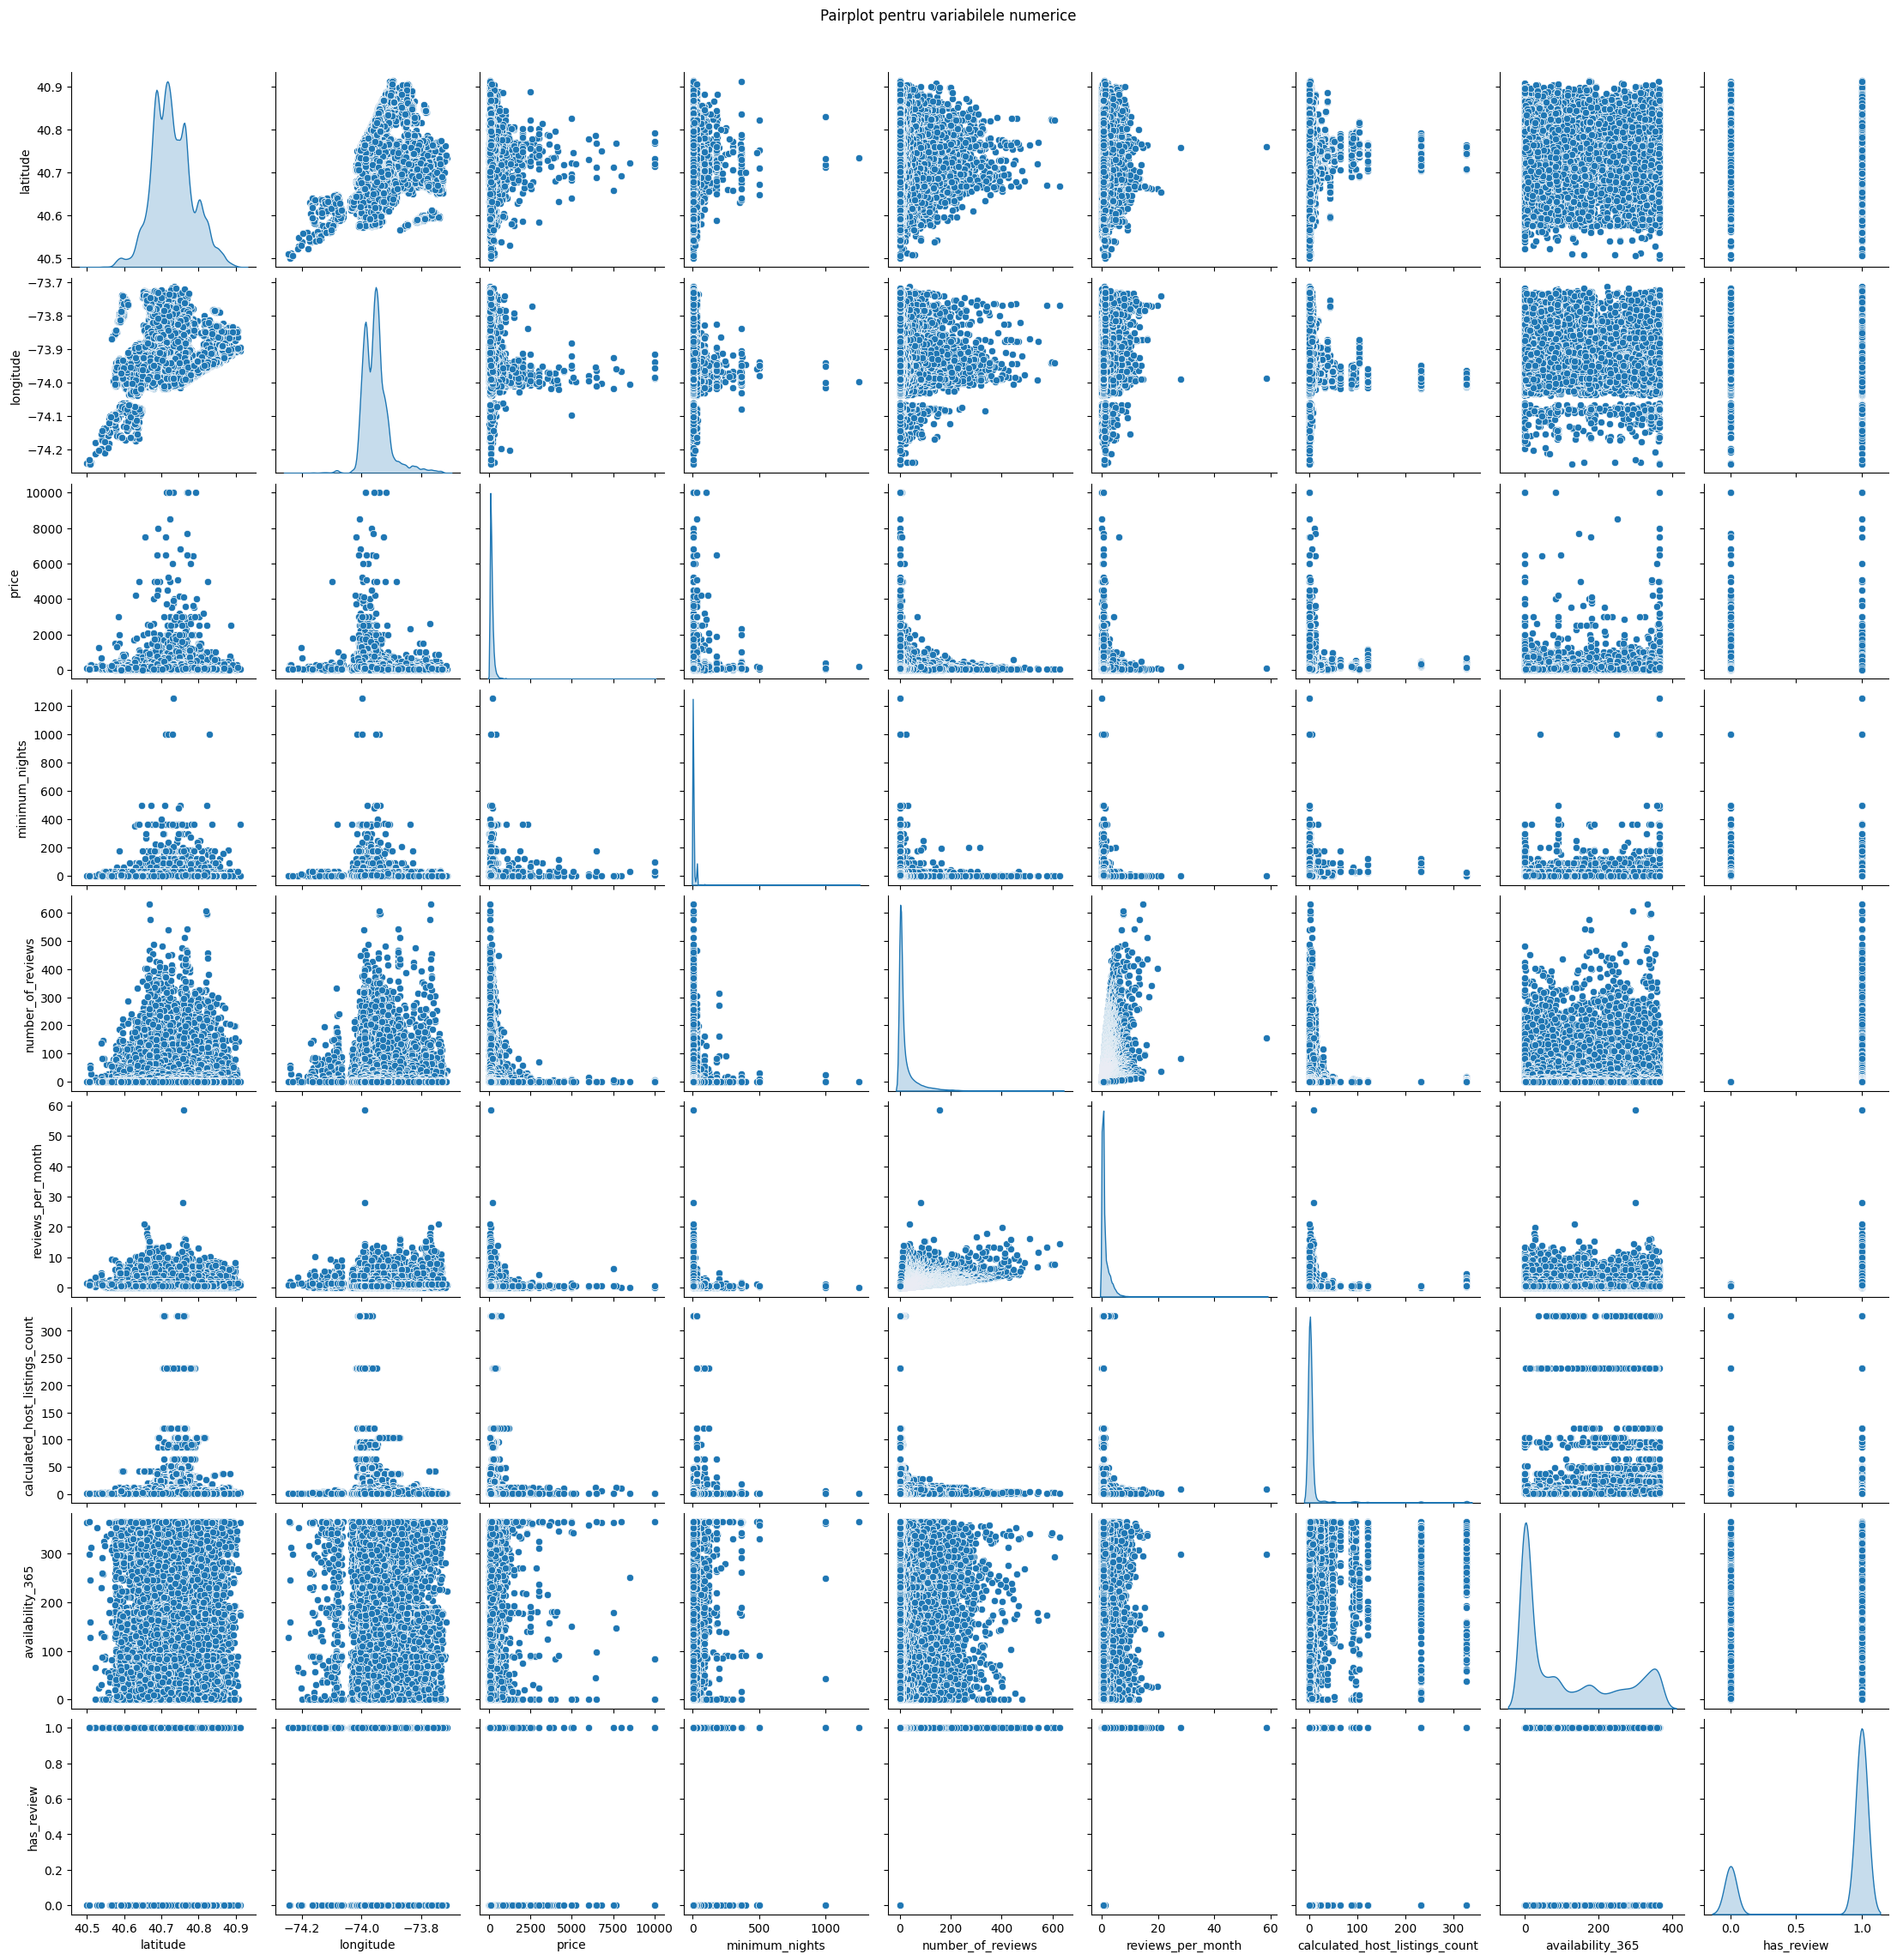

In [70]:

plot_pairplot_numeric(df, numerical_cols)





Diagonală: arată distribuția (histograme sau plot de densitate) pentru fiecare variabilă numerică în parte.

Zona off-diagonală: fiecare celulă reprezintă un scatter plot între două variabile numerice diferite.

Pe axa X se află variabila numerică de pe coloana Pairplot-ului.

Pe axa Y se află variabila numerică de pe rândul Pairplot-ului.


Cum te uiți la diagrame:

Pe diagonală:
 vezi forma distribuției (cât de asimetrică e, unde se concentrează majoritatea datelor, dacă există două vârfuri – bimodal, etc.).



**Off-diagonal (scatter plots):**

-cauți tipare precum:

Relații liniare (un nor de puncte cu panta pozitivă sau negativă).

Grupări distincte (clustere).

Outlieri (puncte foarte depărtate de rest).

Exemplu:
 minimum_nights

Cel mai adesea are valori mici (1-5 nopți) și un număr mic de outlieri cu 30, 100 sau chiar 365 de nopți minime.
Interpretare: Majoritatea proprietăților permit închirieri pe termen scurt, dar există câteva care cer sejururi lungi.

price vs. minimum_nights

majoritatea punctelor sunt sub 10 nopți, iar prețul e răspândit. Poți observa câteva listări cu minimum_nights foarte mare, la prețuri variate.
Interpretare: Nu pare o relație lineară clară;





In [193]:
def plot_boxplot_cat_numeric(df, cat_col, num_col):
    """
    Creează un boxplot care compară distribuția unei variabile numerice (num_col)
    în funcție de o variabilă categorică (cat_col).
    """
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=cat_col, y=num_col, palette='viridis')
    plt.title(f"Boxplot pentru {num_col} în funcție de {cat_col}")
    plt.xlabel(cat_col)
    plt.ylabel(num_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_boxplots_for_all_cats(df, numeric_col, cat_cols):
    """
    Creează boxplot-uri pentru o variabilă numerică, împărțită pe mai multe coloane categorice.
    De exemplu, dacă cat_cols = ['neighbourhood_group', 'room_type'],
    se vor crea două boxplot-uri diferite.
    """
    for cat_col in cat_cols:
        if cat_col in df.columns:
            plot_boxplot_cat_numeric(df, cat_col, numeric_col)
        else:
            print(f"Coloana {cat_col} nu există în DataFrame.")

<ipython-input-159-ba7657634de9>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y=num_col, palette='viridis')


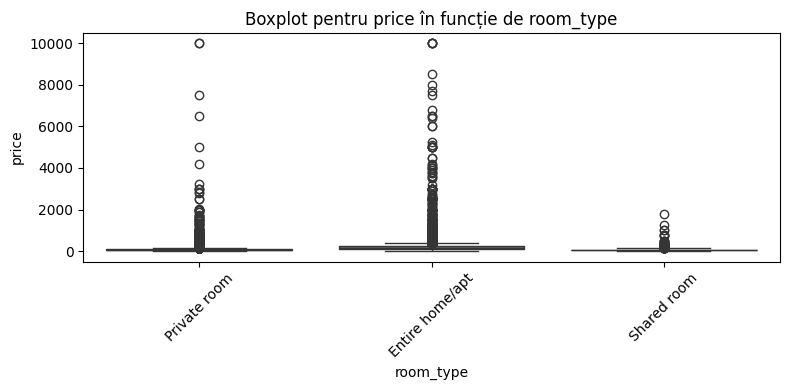

In [160]:
# 2. Boxplot numeric vs. categoric
# Exemplu: comparăm 'price' (numeric) în funcție de 'room_type' (categoric)
plot_boxplot_cat_numeric(df, cat_col='room_type', num_col='price')



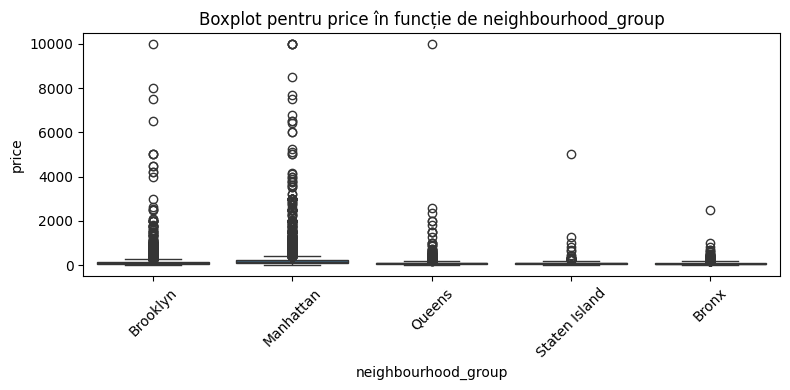

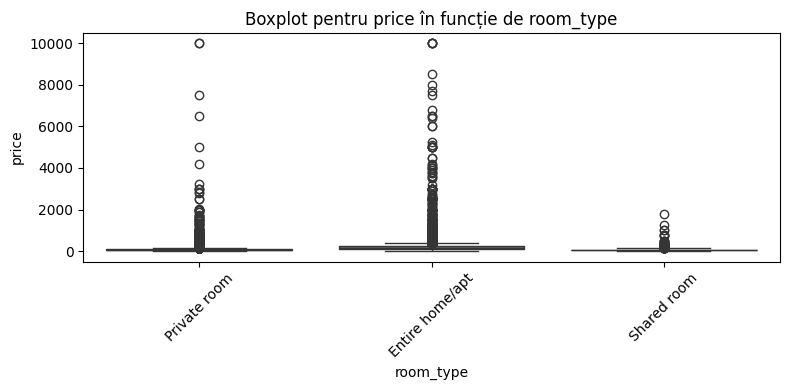

In [307]:
# 3. Boxplot pentru mai multe coloane categorice
# Exemplu: 'neighbourhood_group' și 'room_type' vs. 'price'
categorical_cols = ['neighbourhood_group', 'room_type']
plot_boxplots_for_all_cats(df, numeric_col='price', cat_cols=categorical_cols)

Elemente de bază

Cutia (box):


Delimitată de Quartila 1 (Q1) și Quartila 3 (Q3).

Linia orizontală din interiorul cutiei reprezintă Mediana (Q2).

Acest „dreptunghi” arată unde se află 50% din valori (între Q1 și Q3).

Mustățile (whiskers): De regulă, se întind până la 1.5 * IQR (unde IQR = Q3 - Q1) peste limitele Q1 și Q3. Valorile dincolo de aceste limite sunt considerate potențiali outlieri.

Punctele individuale (outliers): Reprezintă prețuri neobișnuit de mari (sau mici), care depășesc intervalul considerat „normal” pentru acel tip de cameră.
Nu înseamnă neapărat că sunt eronate; pot fi proprietăți de lux sau oferte rare.

Private room:

Mediana (Q2) este relativ mică față de celelalte tipuri, indicând că jumătate dintre camerele private au un preț sub această valoare.
Există, totuși, puncte outlier care depășesc chiar și 2000$, semn că există câteva camere private la preț foarte mare (posibil camere de lux sau listări greșite).
Entire home/apt:

Mediana este cea mai mare dintre cele trei tipuri de camere, ceea ce confirmă așteptarea că închirierea întregii locuințe costă mai mult.
Observi, de asemenea, numeroase outliers la prețuri de peste 2000$, 3000$ etc., care pot reprezenta apartamente/penthouse-uri de lux, vile sau listări unice.
Shared room:

Mediana și quartilele sunt cele mai mici, indicând că majoritatea camerelor partajate sunt mai ieftine.
Există și aici outliers, dar mult mai puțini și nu atât de ridicați ca în celelalte categorii.


Ce sunt outlierii și de ce contează?

Outlier = valoare care se află la extremitățile distribuției, semnificativ mai mare (sau mai mică) decât majoritatea datelor.


De ce contează?

Pot denatura statisticile descriptive (media, deviația standard).
Pot influența negativ antrenarea modelelor de Machine Learning, mai ales modele sensibile la valori extreme (ex.: regresie liniară).

Uneori, outlierii reprezintă date valoroase (ex.: proprietăți de lux, erori de introducere a datelor, etc.).

Scopul: Nu întotdeauna vrem să eliminăm outlierii, ci să-i identificăm și să decidem cum îi tratăm, în funcție de contextul proiectului.

Cea mai uzuală metodă pentru date cu distribuție necunoscută (adesea asimetrică) este IQR (Interquartile Range).


IQR=Q3−Q1

Q1 = Quartila 1 (25% din date sunt sub Q1).

Q3 = Quartila 3 (75% din date sunt sub Q3).

Limite:

lower_bound=Q1−1.5×IQR

upper_bound=Q3+1.5×IQR

Valorile care se află în afara acestui interval [lower_bound,upper_bound] sunt considerate outlieri potențiali.

In [400]:
def find_outliers_iqr(df, col):
    """
    Identifică outlierii într-o coloană numerică folosind Metoda IQR.
    Returnează un DataFrame cu outlierii respectivi.
    """
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_df = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers_df


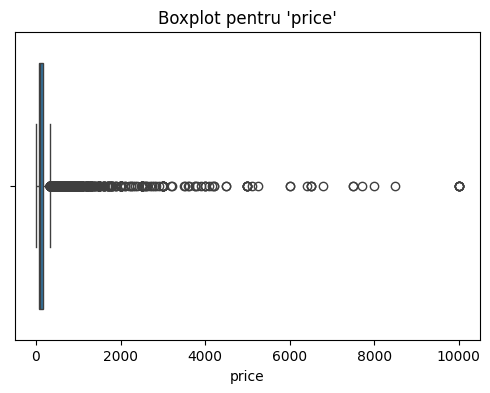

In [401]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.title("Boxplot pentru 'price'")
plt.show()

Număr de outlieri la 'price': 3
Coloana: price
Limita inferioară: -90.00, Limita superioară: 334.00
Număr de outlieri: 2972
--------------------------------------------------


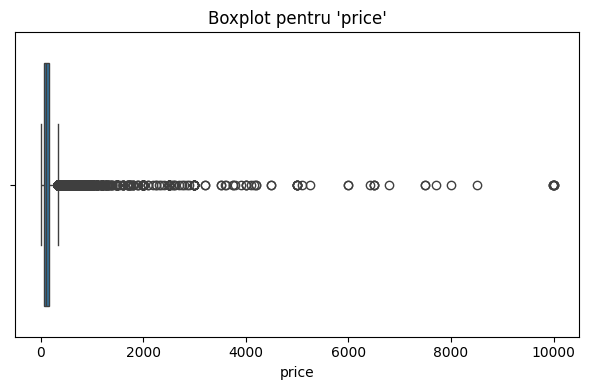

Coloana: minimum_nights
Limita inferioară: -5.00, Limita superioară: 11.00
Număr de outlieri: 6607
--------------------------------------------------


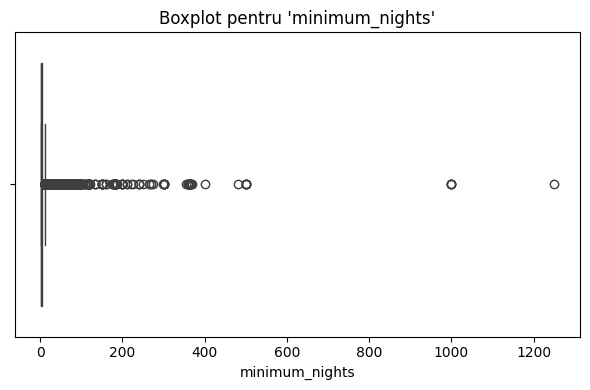

Coloana: number_of_reviews
Limita inferioară: -33.50, Limita superioară: 58.50
Număr de outlieri: 6021
--------------------------------------------------


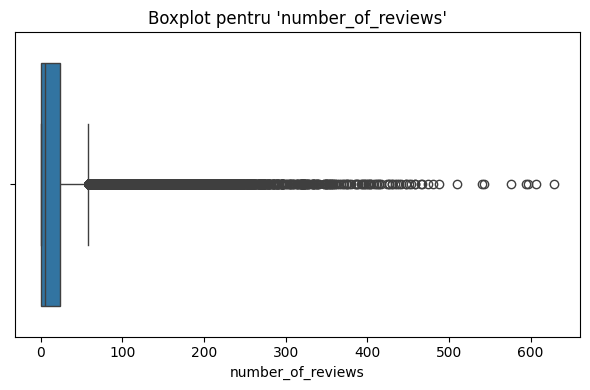

Coloana: reviews_per_month
Limita inferioară: -1.67, Limita superioară: 3.53
Număr de outlieri: 4103
--------------------------------------------------


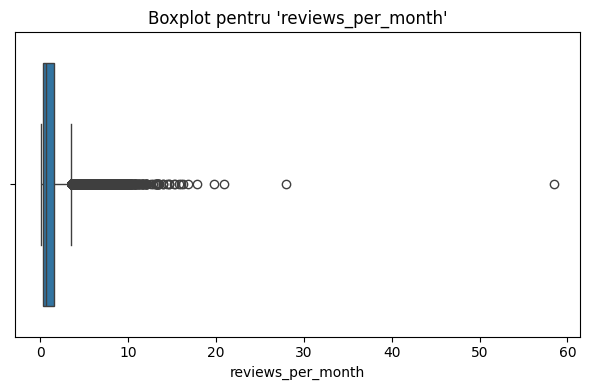

In [402]:
# 2. Funcție pentru identificarea outlierilor folosind metoda IQR
def find_outliers_iqr(df, col):
    """
    Funcție care calculează limitele inferioare și superioare folosind metoda IQR pentru o coloană numerică
    și returnează valorile limite și un DataFrame cu outlierii respectivi.
    """
    Q1 = df[col].quantile(0.25)       # Calculăm Quartila 1
    Q3 = df[col].quantile(0.75)       # Calculăm Quartila 3
    IQR = Q3 - Q1                   # Intervalul intercuartilic
    lower_bound = Q1 - 1.5 * IQR      # Limita inferioară
    upper_bound = Q3 + 1.5 * IQR      # Limita superioară
    outliers_df = df[(df[col] < lower_bound) | (df[col] > upper_bound)]  # Selectăm valorile care ies din interval
    return lower_bound, upper_bound, outliers_df

outliers_price = find_outliers_iqr(df, 'price')
print(f"Număr de outlieri la 'price': {len(outliers_price)}")

# 3. Lista coloanelor relevante pentru analiza outlierilor
relevant_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']

# 4. Pentru fiecare coloană relevantă, calculăm și afișăm limitele și numărul de outlieri, apoi generăm grafice
for col in relevant_cols:
    if col in df.columns:
        # Calculăm limitele și outlierii pentru coloana curentă
        lower_bound, upper_bound, outliers_df = find_outliers_iqr(df, col)
        print(f"Coloana: {col}")
        print(f"Limita inferioară: {lower_bound:.2f}, Limita superioară: {upper_bound:.2f}")
        print(f"Număr de outlieri: {len(outliers_df)}")
        print("-" * 50)

        # 4a. Plotăm un boxplot pentru coloana respectivă
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot pentru '{col}'")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()


Odată identificați outlierii, trebuie să decizi ce faci cu ei. Nu există o regulă universală; depinde de context:

***Eliminarea outlierilor***

Pro: Poate îmbunătăți performanța modelelor sensibile (regresii liniare).

Contra: Poți pierde informații valoroase (de ex.: proprietăți de lux reale).

*Eliminăm outlierii din 'price'*

df_no_outliers = df[~df.index.isin(outliers_price.index)]

***Transformare logaritmică***

Pro: Reduce asimetria distribuției și efectul valorilor mari.
Contra: Nu rezolvă complet problema dacă outlierii sunt extrem de mari sau eronați.


df['price_log'] = np.log1p(df['price'])  # log(price + 1)

***\capping***

Pro: Taie valorile peste un anumit percentil (ex. 1% și 99%), înlocuindu-le cu limitele.

Contra: Poate distorsiona datele dacă nu e aplicată cu atenție.

lower_perc = df['price'].quantile(0.01)
upper_perc = df['price'].quantile(0.99)

df['price_winsor'] = np.where(df['price'] < lower_perc, lower_perc,
                       np.where(df['price'] > upper_perc, upper_perc, df['price']))



***Păstrarea outlierilor***

Pro: Poate fi necesar dacă datele reprezintă realitatea (proprietăți foarte scumpe).

Contra: Poate afecta precizia modelelor.

Exemplu: Dacă obiectivul tău e să modelezi inclusiv segmentul de lux, vei dori să îi păstrezi.

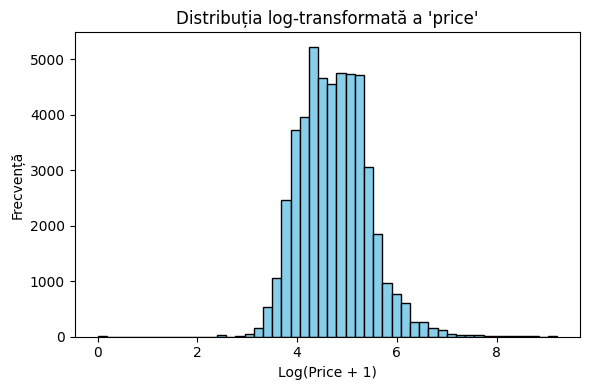

In [404]:
#SAU
# Removing outliers based on 'price' and 'minimum_nights' (top 1%)
price_upper_limit = df['price'].quantile(0.99)
minimum_nights_upper_limit = df['minimum_nights'].quantile(0.99)

df = df[(df['price'] <= price_upper_limit) & (df['minimum_nights'] <= minimum_nights_upper_limit)]
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,has_review,review_year
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,1,2018.0
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,1,2019.0
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.61,1,365,0,NaN
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,1,2019.0
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,1,2018.0


Mai departe, după ce am tratat outlierii și am aplicat transformări (de exemplu, transformarea logaritmică pentru „price”), următorii pași în EDA sunt analiza corelațiilor între variabile, extragerea de noi caracteristici (feature engineering) și pregătirea datelor pentru modelare.


1. Analiza Corelațiilor între Variabile

Scopul:


Identificarea relațiilor liniare între variabilele numerice.
Detectarea colinearității (variabile care se corelează foarte puternic) ce pot afecta modelele predictive.

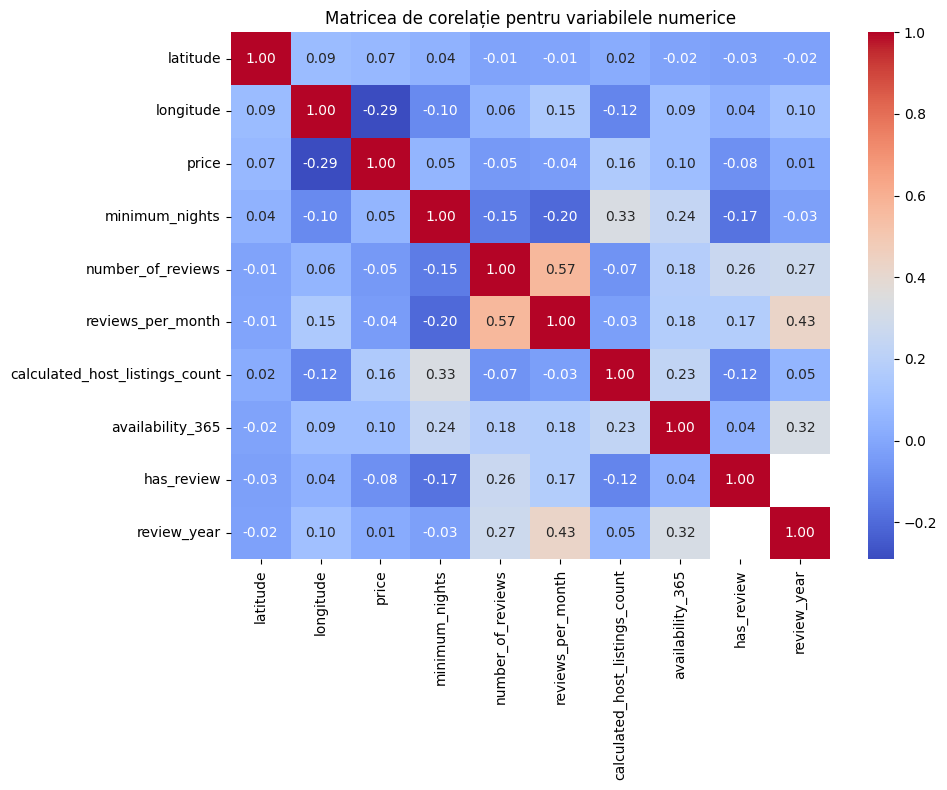

In [405]:

numerical_cols = df.select_dtypes(include=[np.number]).columns

corr_matrix = df[numerical_cols].corr()

# Vizualizăm matricea de corelație cu un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matricea de corelație pentru variabilele numerice")
plt.tight_layout()
plt.show()

Pe axele X și Y apar aceleași variabile numerice (latitude, longitude, price, minimum_nights, number_of_reviews, etc.).

Celula din intersecția rândului i cu coloana j arată coeficientul de corelație Pearson între variabila i și variabila j.

Scara de culori (de la albastru la roșu) indică semnul și magnitudinea corelației:

Roșu intens = corelație pozitivă puternică (spre +1).

Albastru intens = corelație negativă puternică (spre -1).

Valori apropiate de 0 (culori deschise) = relație liniară slabă sau inexistentă.

**interpretarea numerică**

Corelație peste +0.7 sau sub -0.7: considerată de obicei puternică.

Corelație între +0.3 și +0.7 sau -0.3 și -0.7: considerată moderată.

Corelație între -0.3 și +0.3: considerată slabă.

Aceste praguri sunt doar *orientative*; importanța practică depinde și de contextul datelor.


number_of_reviews vs. reviews_per_month are o corelație semnificativă (~0.57). Într-un model, ai putea folosi doar una dintre ele sau să creezi un feature derivat (ex.: scor de popularitate)

Feature Engineering: Extragerea de Noi Caracteristici

Scopul:


Să valorificăm informațiile existente pentru a crea noi variabile care pot îmbunătăți performanța modelelor predictive.

In [407]:
# Asigurăm conversia la datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Extragerea anului, lunii și zilei săptămânii
df['review_year'] = df['last_review'].dt.year
df['review_month'] = df['last_review'].dt.month
df['review_dayofweek'] = df['last_review'].dt.dayofweek

df = df.drop(columns=['last_review'])


KeyError: 'last_review'

In [373]:
# Categorizing availability into meaningful groups (Low, Medium, High)
df['availability_category'] = pd.cut(
    df['availability_365'],
    bins = [-1, 60, 200, 365],
    labels = ['Low', 'Medium', 'High']
)

In [408]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_review,review_year,review_month,review_dayofweek
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,1,2018.0,10.0,4.0
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,1,2019.0,5.0,1.0
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.61,1,365,0,NaN,NaN,NaN
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,1,2019.0,7.0,4.0
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,1,2018.0,11.0,0.0


In [409]:
from geopy.distance import geodesic
city_center = (40.7580, -73.9855)
df['distance_to_center'] = df.apply(
    lambda x: geodesic((x['latitude'], x['longitude']), city_center).km, axis = 1
)

In [410]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,has_review,review_year,review_month,review_dayofweek,distance_to_center
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,1,2018.0,10.0,4.0,12.321998
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,1,2019.0,5.0,1.0,0.507861
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.61,1,365,0,NaN,NaN,NaN,6.756122
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,1,2019.0,7.0,4.0,8.378165
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,1,2018.0,11.0,0.0,5.702325


**ENCODAREA **

În esență, encodarea transformă variabilele categorice (de tip text sau discrete) în formate numerice, astfel încât modelele să poată lucra cu ele. I

One-Hot Encoding

Ce FACE:
Transformă fiecare categorie într-o coloană binară. Pentru o variabilă cu
k categorii, se creează  𝑘
coloane (sau 𝑘−1 dacă eliminăm prima categorie pentru a evita colinearitatea dummy).

Când se folosește:

Când numărul de categorii este moderat.

Când nu există o ordine naturală între categorii.

In [87]:

df_encode_exemple = pd.DataFrame({
    'room_type': ['Entire home/apt', 'Private room', 'Shared room', 'Entire home/apt']
})

# One-hot encoding folosind pandas.get_dummies
df_onehot = pd.get_dummies(df_encode_exemple, columns=['room_type'], drop_first=True)
print(df_onehot)
'''
Fiecare categorie devine o coloană cu valori 0/1, indicând prezența sau absența categoriei.
Această metodă este simplă și ușor de interpretat, însă poate crește dimensionalitatea dacă numărul de categorii este mare.'''

   room_type_Private room  room_type_Shared room
0                   False                  False
1                    True                  False
2                   False                   True
3                   False                  False


**Label Encoding**

Ce face:

Atribuie un număr întreg fiecărei categorii. De exemplu, 'Private room' = 0, 'Entire home/apt' = 1, 'Shared room' = 2.

Când se folosește:

Pentru variabilele categorice ordinale (unde există o ordine naturală între categorii).

Pentru algoritmi care pot interpreta valorile ordinale, dar atenție: pentru variabile nominale, acest tip de codificare poate induce o relație ordonată artificială.


In [88]:
from sklearn.preprocessing import LabelEncoder

df_label_enoder = pd.DataFrame({
    'room_type': ['Entire home/apt', 'Private room', 'Shared room', 'Entire home/apt']
})

le = LabelEncoder()
df_label_enoder['room_type_encoded'] = le.fit_transform(df_label_enoder['room_type'])
print(df_label_enoder)

         room_type  room_type_encoded
0  Entire home/apt                  0
1     Private room                  1
2      Shared room                  2
3  Entire home/apt                  0


**Target Encoding**
Ce face:
Înlocuiește fiecare categorie cu o statistică a țintei (ex.: media valorii țintă) calculată pentru acea categorie.

Când se folosește:

Când ai un număr mare de categorii și one-hot encoding ar genera prea multe coloane.
În special pentru modele de regresie, când vrei să capturezi impactul unei categorii asupra valorii țintă.

In [ ]:

# Să presupunem că avem un DataFrame cu 'room_type' și prețul (price)
df_target = pd.DataFrame({
    'room_type': ['Entire home/apt', 'Private room', 'Shared room', 'Entire home/apt', 'Private room'],
    'price': [150, 80, 50, 200, 90]
})

# Calculăm media prețului pentru fiecare categorie
target_mean = df_target.groupby('room_type')['price'].mean()
df_target['room_type_target_encoded'] = df_target['room_type'].map(target_mean)
print(df_target)

**Frequency Encoding**

**Ce face:**
Înlocuiește fiecare categorie cu frecvența sa (numărul de apariții sau proporția).

Când se folosește:

Când vrei să capturezi informația despre cât de comună este o categorie.
Poate fi combinată cu target encoding pentru a reduce zgomotul.


In [89]:
df_frequency = pd.DataFrame({
    'room_type': ['Entire home/apt', 'Private room', 'Shared room', 'Entire home/apt', 'Private room']
})

# Calculăm frecvența pentru fiecare categorie
freq_encoding = df_frequency['room_type'].value_counts(normalize=True)
df_frequency['room_type_freq_encoded'] = df_frequency['room_type'].map(freq_encoding)
print(df_frequency)

'''
Valorile devin proporția apariției fiecărei categorii. Aceasta poate ajuta modele care interpretează frecvența ca un indicator al relevanței sau popularității
'''

         room_type  room_type_freq_encoded
0  Entire home/apt                     0.4
1     Private room                     0.4
2      Shared room                     0.2
3  Entire home/apt                     0.4
4     Private room                     0.4


'\nValorile devin proporția apariției fiecărei categorii. Aceasta poate ajuta modele care interpretează frecvența ca un indicator al relevanței sau popularității\n'

<ipython-input-169-f3389c7e2b63>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room_type', data=df, palette='Set3')


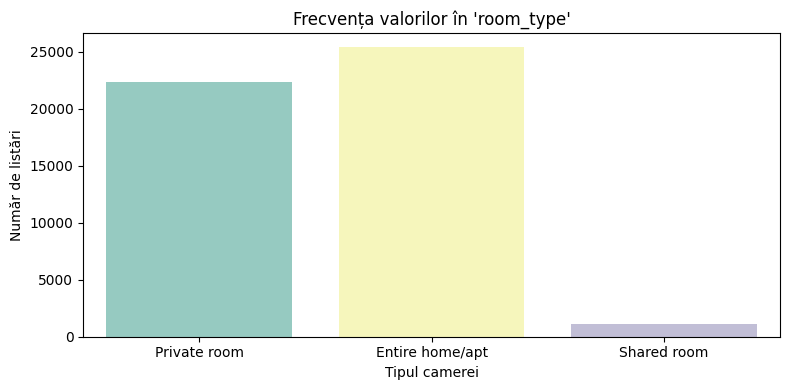

<ipython-input-169-f3389c7e2b63>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neighbourhoods.index, y=top_neighbourhoods.values, palette='viridis')


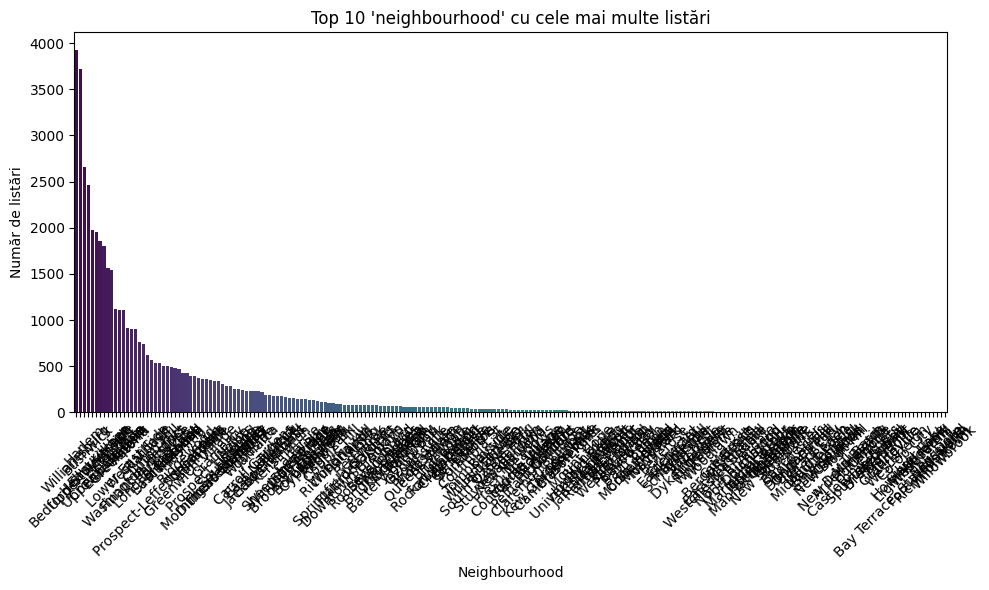

In [169]:


# 3. Vizualizarea distribuției pentru variabila 'room_type'
plt.figure(figsize=(8, 4))
sns.countplot(x='room_type', data=df, palette='Set3')
plt.title("Frecvența valorilor în 'room_type'")
plt.xlabel("Tipul camerei")
plt.ylabel("Număr de listări")
plt.tight_layout()
plt.show()

# 4. Pentru variabila 'neighbourhood' care are multe categorii, afișăm doar top 10 cele mai frecvente
top_neighbourhoods = df['neighbourhood'].value_counts() #ADD NLARGEST
plt.figure(figsize=(10, 6))
sns.barplot(x=top_neighbourhoods.index, y=top_neighbourhoods.values, palette='viridis')
plt.title("Top 10 'neighbourhood' cu cele mai multe listări")
plt.xlabel("Neighbourhood")
plt.ylabel("Număr de listări")
plt.xticks(rotation=45)                # Rotim etichetele pentru vizibilitate
plt.tight_layout()
plt.show()

Variabile cu număr redus de categorii (low cardinality)
Exemple:

room_type: (ex.: "Entire home/apt", "Private room", "Shared room")

neighbourhood_group: (ex.: "Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island")
Recomandare: One-Hot Encoding

Variabile cu număr mare de categorii (high cardinality)
Exemplu:

neighbourhood:
Setul conține multe cartiere specifice, ceea ce poate genera sute de categorii.

Recomandăre: Target Encoding:

Înlocuiește fiecare categorie cu media valorii țintă (de exemplu, media prețului) pentru acea categorie.

Motiv: Capturăm impactul specific al fiecărui cartier asupra prețului, fără a crea sute de coloane.



In [411]:
# 2. One-Hot Encoding pentru variabilele cu low cardinality:
# Aplicăm one-hot encoding pentru 'room_type' și 'neighbourhood_group'
df_encoded = pd.get_dummies(df, columns=['room_type', 'neighbourhood_group'], drop_first=True)

# 3. Encoding pentru variabila 'neighbourhood' (high cardinality)
# a. Frequency Encoding:
# Calculăm frecvența relativă pentru fiecare cartier și o mapăm la 'neighbourhood'
neighbourhood_freq = df['neighbourhood'].value_counts(normalize=True)
df_encoded['neighbourhood_freq'] = df['neighbourhood'].map(neighbourhood_freq)
'''
# b. Target Encoding:
# Dacă obiectivul tău este, de exemplu, predicția prețului, poți înlocui fiecare cartier cu media prețului din acel cartier.
# Pentru exemplificare, vom presupune că ținta este 'price'.
target_mean = df.groupby('neighbourhood')['price'].mean()
df_encoded['neighbourhood_target'] = df['neighbourhood'].map(target_mean)
'''

'''
# 5. Transformarea variabilei de tip dată 'last_review'
# Convertim 'last_review' la tip datetime
df_encoded['last_review'] = pd.to_datetime(df_encoded['last_review'], errors='coerce')
# Extragem informații din 'last_review'
df_encoded['review_year'] = df_encoded['last_review'].dt.year
df_encoded['review_month'] = df_encoded['last_review'].dt.month
df_encoded['review_dayofweek'] = df_encoded['last_review'].dt.dayofweek
# Dacă nu mai este necesară variabila originală, o putem elimina
df_encoded = df_encoded.drop(columns=['last_review'])
'''

# Înlocuim valorile NaN din aceste coloane cu -1 pentru a indica că nu există recenzie
df_encoded['review_year'] = df_encoded['review_year'].fillna(-1).astype(int)
df_encoded['review_month'] = df_encoded['review_month'].fillna(-1).astype(int)
df_encoded['review_dayofweek'] = df_encoded['review_dayofweek'].fillna(-1).astype(int)

# 6. Vizualizăm primele rânduri pentru a verifica transformările
print(df_encoded.head())

  neighbourhood  latitude  longitude  price  minimum_nights  \
0    Kensington  40.64749  -73.97237    149               1   
1       Midtown  40.75362  -73.98377    225               1   
2        Harlem  40.80902  -73.94190    150               3   
3  Clinton Hill  40.68514  -73.95976     89               1   
4   East Harlem  40.79851  -73.94399     80              10   

   number_of_reviews  reviews_per_month  calculated_host_listings_count  \
0                  9               0.21                               6   
1                 45               0.38                               2   
2                  0               0.61                               1   
3                270               4.64                               1   
4                  9               0.10                               1   

   availability_365  has_review  ...  review_month  review_dayofweek  \
0               365           1  ...            10                 4   
1               355       

In [412]:
cols_to_drop = df_encoded.select_dtypes(include=['object']).columns
print("Eliminăm coloanele:", cols_to_drop.tolist())

df_encoded = df_encoded.drop(columns=cols_to_drop)

Eliminăm coloanele: ['neighbourhood']


In [413]:
df_encoded = df_encoded.drop(columns = ['latitude', 'longitude'])

Acum trecem la **standardizare și normalizare**, două tehnici esențiale de scalare a datelor pentru a pregăti variabilele numerice înainte de a le folosi în modele de machine learning. Aceste metode ajută la reducerea diferențelor de scară între variabile și la îmbunătățirea performanței anumitor algoritmi

Modele precum regresia liniară, SVM, k-NN sau rețelele neuronale sunt influențate de diferențele de scară între variabile.


Dacă o variabilă are valori mult mai mari decât alta, aceasta poate domina funcția de cost și poate determina rezultatele modelului.


Algoritmii de optimizare (ex.: gradient descent) funcționează mai bine când datele sunt pe o scară similară.


** Standardizare (StandardScaler)**

Ce face:

Transformă datele astfel încât să aibă medie 0 și deviație standard 1.

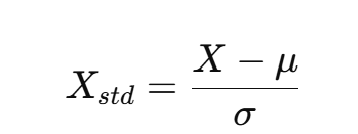

Când se folosește:

Când distribuția datelor este aproximativ normală sau când vrei să păstrezi relația între valorile diferitelor variabile.

In [414]:
from sklearn.preprocessing import StandardScaler

#
scaler = StandardScaler()

# Aplicăm standardizarea pe coloana 'price'

df_encoded['price'] = scaler.fit_transform(df_encoded[['price']])
# Verificăm media și deviația standard după standardizare
print("Media după standardizare:", df_encoded['price'].mean())
print("Deviația standard după standardizare:", df_encoded['price'].std())

Media după standardizare: -1.2512891441473243e-16
Deviația standard după standardizare: 1.0000105832985344


Normalizare (MinMaxScaler)
**Ce face:**

Scalează datele într-un interval definit, de obicei [0,1].

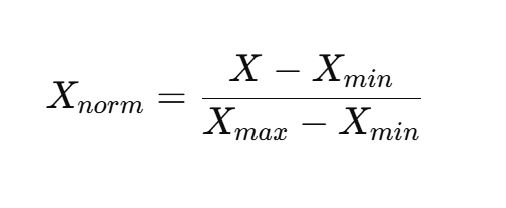

Când se folosește:

Când vrei să păstrezi proporționalitatea între valorile din setul de date.
Utilă în special când folosești algoritmi care presupun că valorile de intrare sunt limitate (ex.: rețele neuronale cu funcții de activare care lucrează optim în intervalul  [0,1]).

In [204]:
from sklearn.preprocessing import MinMaxScaler

# Creăm un obiect MinMaxScaler care scalează datele între 0 și 1 (implicit)
minmax_scaler = MinMaxScaler()

# Aplicăm normalizarea pe coloana 'price'
df_encoded['price_normalized'] = minmax_scaler.fit_transform(df[['price']])

# Verificăm valorile minime și maxime după normalizare
print("Valoare minimă după normalizare:", df_encoded['price_normalized'].min())
print("Valoare maximă după normalizare:", df_encoded['price_normalized'].max())

Valoare minimă după normalizare: 0.0
Valoare maximă după normalizare: 1.0


In [417]:

scaler = StandardScaler()
numerical_cols = df_encoded.select_dtypes(include=[np.number]).columns

df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# Displaying the final dataframe structure after feature engineering
print("Displaying DataFrame after feature engineering:")
print(df_encoded.head())

# Converting boolean columns explicitly to integers
bool_cols = df_encoded.select_dtypes(include = ['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Confirming final changes clearly
print("\nConfirming DataFrame structure after converting booleans:")
print(df_encoded.head())

Displaying DataFrame after feature engineering:
      price  minimum_nights  number_of_reviews  reviews_per_month  \
0  0.184172       -0.558095          -0.327370          -0.678237   
1  1.027711       -0.558095           0.473445          -0.567850   
2  0.195271       -0.313815          -0.527574          -0.418503   
3 -0.481780       -0.558095           5.478538           2.198324   
4 -0.581673        0.541164          -0.327370          -0.749664   

   calculated_host_listings_count  availability_365  has_review  review_year  \
0                       -0.033537          1.949200    0.497717     0.497353   
1                       -0.154796          1.872656    0.497717     0.498595   
2                       -0.185110          1.949200   -2.009174    -2.009172   
3                       -0.185110          0.640302    0.497717     0.498595   
4                       -0.185110         -0.844648    0.497717     0.497353   

   review_month  review_dayofweek  distance_to_center  r

În cazul nostru, am aplicat transformarea logaritmică pe variabila "price" pentru a obține "price_log", deoarece distribuția prețurilor este foarte asimetrică și o transformare logaritmică ajută la stabilizarea variației și la îmbunătățirea performanței modelelor. Totuși, coloana originală "price" rămâne în setul de date.

Ce trebuie să facem cu cele două variabile?
Alegerea țintei:
Pentru antrenarea modelului, trebuie să alegem una dintre ele ca variabilă țintă (target). De regulă, se folosește "price_log" deoarece are o distribuție mai apropiată de normalitate, facilitând astfel învățarea modelului.


Pentru a evita confuzia sau posibile scurgeri de informații (data leakage), este recomandat să eliminăm "price" din setul de caracteristici dacă am folosit-o și ca target sau dacă nu mai este necesară după transformare.

In [419]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

target = 'price'

# Eliminăm coloana țintă din setul de caracteristici
X = df_encoded.drop([target], axis=1)
y = df_encoded[target]

# Împărțim datele în seturi de antrenare (80%) și test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inițializăm și antrenăm modelul de regresie liniară
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)



# Facem predicții pe setul de test
y_pred = lr_model.predict(X_test)

# Valorile reale
y_test_original = y_test

# Calculăm metrici de evaluare pe scara originală
mae = mean_absolute_error(y_test_original, y_pred)
mse = mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("Rezultatele modelului de regresie liniară:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)


Rezultatele modelului de regresie liniară:
Mean Absolute Error (MAE): 0.5162152163031981
Mean Squared Error (MSE): 0.5830987004867296
R2 Score: 0.4342134730195153


In [420]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import warnings

# Dezactivăm avertismentele pentru claritate
warnings.filterwarnings('ignore')

# Presupunem că df_encoded este DataFrame-ul tău preprocesat
# Dacă ai folosit transformarea log pentru preț, vom folosi 'price_log' ca target,
# altfel, se va folosi 'price'
target = 'price'

# Separăm caracteristicile (features) și ținta (target)
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# Verificăm și păstrăm doar coloanele numerice (modelele de ML necesită variabile numerice)
X = X.select_dtypes(include=[np.number])

# Împărțim datele în seturi de antrenare (80%) și test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Modelul Random Forest

# Inițializăm modelul Random Forest cu 100 de arbori și un seed fix pentru reproducibilitate
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Antrenăm modelul pe datele de antrenare
rf_model.fit(X_train, y_train)
# Facem predicții pe setul de test
rf_pred = rf_model.predict(X_test)

### Modelul XGBoost

# Inițializăm modelul XGBoost cu 100 de estimatori și seed fix
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
# Antrenăm modelul pe datele de antrenare
xgb_model.fit(X_train, y_train)
# Facem predicții pe setul de test
xgb_pred = xgb_model.predict(X_test)

### Evaluarea modelelor

# Calculăm metricile pentru Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)

# Calculăm metricile pentru XGBoost
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_r2  = r2_score(y_test, xgb_pred)

# Afișăm rezultatele pentru ambele modele
print("Random Forest:")
print("  MAE:", rf_mae)
print("  MSE:", rf_mse)
print("  R²:", rf_r2)

print("\nXGBoost:")
print("  MAE:", xgb_mae)
print("  MSE:", xgb_mse)
print("  R²:", xgb_r2)


Random Forest:
  MAE: 0.4654390417618143
  MSE: 0.5072422066941445
  R²: 0.507817791012332

XGBoost:
  MAE: 0.4608366951713218
  MSE: 0.5004637662319407
  R²: 0.514394979890052
